# Document Loaders
- Document Loaders are components in langchain used to load data from various sources into a standardized format,which can be used for chunking, embedding, retrieval & generation.
- Load data from different sources.
- Convert it into a standard format (Document Objects)
- Each document usually contains:
    1. page_content -> actual text
    2. metadata -> source info (file name, page number, URL, etc)

## Type of document loaders:
1. File-based Loaders (Use when data is stored locally)
    - Text files → TextLoader
    - PDFs → PyPDFLoader
    - Word docs → UnstructuredWordDocumentLoader
    - CSV → CSVLoader

2. Web loaders (Useful for scraping blogs, ingesting documentation)
    - WebBaseLoader (scrapes web pages)
    - SitemapLoader

3. Database Loaders (Pull structured data into text form)
    - SLQ Databases
    - NoSQL systems

4. Cloud & SaaS loaders (Useful for enterprise pipelines)
    - Google Drive
    - Notion
    - Slack
    - Confluence

5. Unstructured loaders (Powered by unstructured loaders)
    - scanned PDFs
    - HTML
    - mixed layouts

In [1]:
# TextLoader
from langchain_community.document_loaders import TextLoader
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)

prompt = PromptTemplate(
    template='Write a summary for the following poem - \n {poem}',
    input_variables=['poem']
)

parser = StrOutputParser()
loader = TextLoader('../../data/raw/cricket.txt', encoding='utf-8')
docs = loader.load()

print("Document Object:\n", docs)
print("---------" * 30)
print("Type of docs:\n", type(docs))
print("Number of documents:\n", len(docs))
print("First document content:\n", docs[0].page_content)
print("First document metadata:\n", docs[0].metadata)

chain = prompt | model | parser

print(chain.invoke({'poem':docs[0].page_content}))

d:\Repos\Gen-AI\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Document Object:
 [Document(metadata={'source': '../../data/raw/cricket.txt'}, page_content='Beneath the sun or floodlight\'s gleam,\n\nCricket lives like a waking dream.\n\nA field of green, a willowed sound,\n\nWhere legends rise and tales are found.\n\nFrom dusty lanes where barefoot boys,\n\nChase every run with shrieks of joy,\n\nTo packed arenas roaring loud,\n\nThe game unites a global crowd.\n\nA coin is tossed, the captains stare,\n\nAs tension thickens in the air.\n\nBat or bowl? A choice so bold,\n\nA story new begins, retold.\n\nThe openers walk, calm yet brave,\n\nEach stride a wave upon the wave.\n\nThey face the ball with narrowed eyes,\n\nAs silence grips the watching skies.\n\nThe bowler runs, a rhythmic beat,\n\nLike thunder galloping on feet.\n\nA leather flash, a wooden crack—\n\nThe ball takes flight, then tumbles back.\n\nA flick through square, a drive through mid,\n\nA lofted shot the fielder missed.\n\nA single, double, sprint for three,\n\nThe crowd erupts in 

PDF Loaders
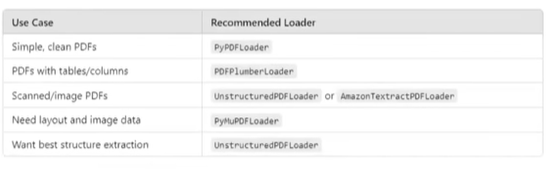

In [2]:
# PyPDFLoader - Not great with scanned PDFs or complex layouts, but works well with text-based PDFs. It extracts text content and metadata from PDF files, making it suitable for processing documents like reports, articles, and academic papers.
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader('../../data/raw/dl-curriculum.pdf')
docs = loader.load()

print("Document Object:\n", docs)
print("---------" * 30)
print("Number of documents:\n", len(docs))
print("First document content:\n", docs[0].page_content)
print("First document metadata:\n", docs[0].metadata)

Document Object:
 [Document(metadata={'producer': 'Skia/PDF m131 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Deep Learning Curriculum', 'source': '../../data/raw/dl-curriculum.pdf', 'total_pages': 23, 'page': 0, 'page_label': '1'}, page_content='CampusXDeepLearningCurriculum\nA.ArtificialNeuralNetworkandhowtoimprovethem\n1.BiologicalInspiration\n● Understandingtheneuronstructure● Synapsesandsignal transmission● Howbiological conceptstranslatetoartificial neurons\n2.HistoryofNeuralNetworks\n● Earlymodels(Perceptron)● BackpropagationandMLPs● The"AI Winter" andresurgenceof neural networks● Emergenceof deeplearning\n3.PerceptronandMultilayerPerceptrons(MLP)\n● Single-layer perceptronlimitations● XORproblemandtheneedfor hiddenlayers● MLParchitecture\n4. LayersandTheirFunctions\n● InputLayer○ Acceptinginput data● HiddenLayers○ Featureextraction● OutputLayer○ Producingfinal predictions\n5.ActivationFunctions'), Document(metadata={'producer': 'Skia/PDF m131 Google 

Directory Loader  
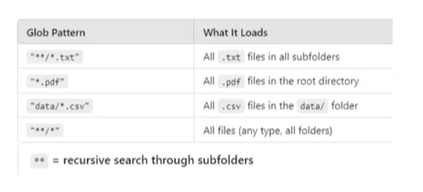

In [3]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

loader = DirectoryLoader(
    path='../../data/raw/',
    glob='*.pdf',
    loader_cls=PyPDFLoader
)

docs = loader.load()

for document in docs:
    print(document.metadata)

{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': '..\\..\\data\\raw\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 0, 'page_label': 'Cover'}
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': '..\\..\\data\\raw\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 1, 'page_label': 'FM1'}
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': '..\\..\\data\\raw\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page':

### Load vs Lazy Load
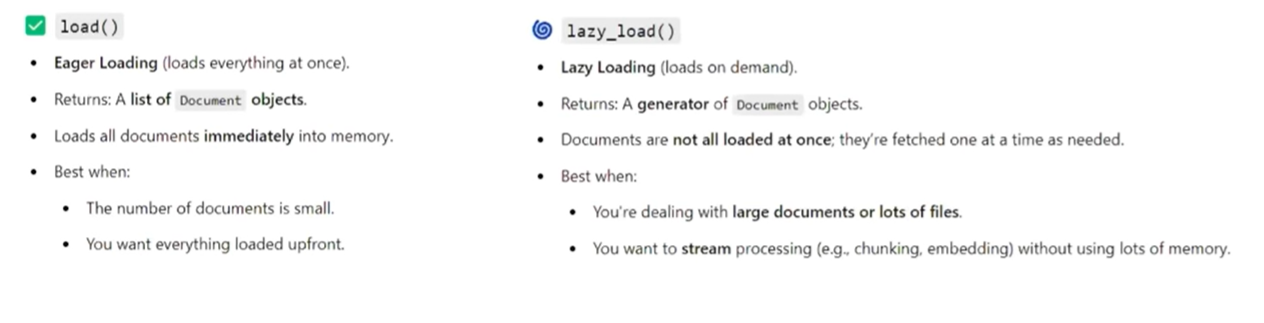

In [4]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

loader = DirectoryLoader(
    path='../../data/raw/',
    glob='*.pdf',
    loader_cls=PyPDFLoader
)

docs = loader.lazy_load()

for document in docs:
    print(document.metadata)

{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': '..\\..\\data\\raw\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 0, 'page_label': 'Cover'}
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': '..\\..\\data\\raw\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 1, 'page_label': 'FM1'}
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': '..\\..\\data\\raw\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page':

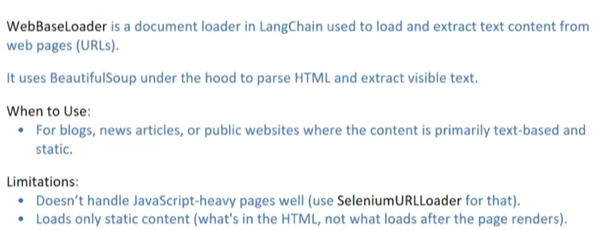

In [5]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv

load_dotenv()

prompt = PromptTemplate(
    template='Answer the following question \n {question} from the following text - \n {text}',
    input_variables=['question','text']
)

parser = StrOutputParser()

url = 'https://www.flipkart.com/apple-macbook-air-m2-16-gb-256-gb-ssd-macos-sequoia-mc7x4hn-a/p/itmdc5308fa78421'
loader = WebBaseLoader(url)

docs = loader.load()
chain = prompt | model | parser

print(chain.invoke({'question':'What is the prodcut that we are talking about?', 'text':docs[0].page_content}))

USER_AGENT environment variable not set, consider setting it to identify your requests.


The text refers to **Flipkart’s reCAPTCHA** – the “Are you a human? Confirming…” verification tool used on the Flipkart site.


In [ ]:
# CSVLoader - Ideal for structured data in CSV format, allowing you to easily load and process tabular data. It reads CSV files and converts each row into a document, making it suitable for tasks like data analysis, machine learning, and natural language processing on structured datasets.
from langchain_community.document_loaders import CSVLoader

loader = CSVLoader(file_path='../../data/raw/Social_Network_Ads.csv')

docs = loader.load()

print("Length of documents:\n", len(docs))
print("Document Objects:\n", docs)
print("----------" * 30)
print("First Document:\n", docs[0])

Length of documents:
 400
Document Objects:
 [Document(metadata={'source': '../../data/raw/Social_Network_Ads.csv', 'row': 0}, page_content='User ID: 15624510\nGender: Male\nAge: 19\nEstimatedSalary: 19000\nPurchased: 0'), Document(metadata={'source': '../../data/raw/Social_Network_Ads.csv', 'row': 1}, page_content='User ID: 15810944\nGender: Male\nAge: 35\nEstimatedSalary: 20000\nPurchased: 0'), Document(metadata={'source': '../../data/raw/Social_Network_Ads.csv', 'row': 2}, page_content='User ID: 15668575\nGender: Female\nAge: 26\nEstimatedSalary: 43000\nPurchased: 0'), Document(metadata={'source': '../../data/raw/Social_Network_Ads.csv', 'row': 3}, page_content='User ID: 15603246\nGender: Female\nAge: 27\nEstimatedSalary: 57000\nPurchased: 0'), Document(metadata={'source': '../../data/raw/Social_Network_Ads.csv', 'row': 4}, page_content='User ID: 15804002\nGender: Male\nAge: 19\nEstimatedSalary: 76000\nPurchased: 0'), Document(metadata={'source': '../../data/raw/Social_Network_Ads.c